In [2]:
# ============================================================
# CARGA DE LIBRERÍAS Y DEL DATASET Auto (ISLR2)
# ============================================================
library(ISLR2)
library(ggplot2)
library(dplyr)
library(tidyr)
library(gridExtra)
library(knitr)

data("Auto")

cat("Dataset 'Auto' cargado correctamente.\n")
cat("Dimensiones:", dim(Auto), "\n")


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Attaching package: 'gridExtra'


The following object is masked from 'package:dplyr':

    combine




Dataset 'Auto' cargado correctamente.
Dimensiones: 392 9 


In [3]:
# ============================================================
# RECONOCIMIENTO DEL DATASET
# ============================================================

cat("============================================================\n")
cat("PREGUNTA 1: ¿Cuántas filas y columnas tiene el dataset?\n")
cat("============================================================\n")
cat("Filas:", nrow(Auto), "\n")
cat("Columnas:", ncol(Auto), "\n")

cat("\n============================================================\n")
cat("PREGUNTA 2: ¿Qué variables numéricas contiene?\n")
cat("============================================================\n")
numericas <- names(Auto)[sapply(Auto, is.numeric)]
cat("Variables numéricas:", paste(numericas, collapse = ", "), "\n")

cat("\n============================================================\n")
cat("PREGUNTA 3: ¿Existen valores nulos? ¿En qué columnas?\n")
cat("============================================================\n")
nulos <- colSums(is.na(Auto))
nulos_pos <- nulos[nulos > 0]
if (length(nulos_pos) > 0) {
  print(nulos_pos)
} else {
  cat("No hay valores nulos en el dataset.\n")
}

cat("\n============================================================\n")
cat("PREGUNTA 4: Variable a analizar\n")
cat("============================================================\n")
cat("Variable elegida: mpg (rendimiento de combustible)\n")

cat("\n============================================================\n")
cat("ESTRUCTURA DEL DATASET\n")
cat("============================================================\n")
str(Auto)

PREGUNTA 1: ¿Cuántas filas y columnas tiene el dataset?
Filas: 392 
Columnas: 9 

PREGUNTA 2: ¿Qué variables numéricas contiene?
Variables numéricas: mpg, cylinders, displacement, horsepower, weight, acceleration, year, origin 

PREGUNTA 3: ¿Existen valores nulos? ¿En qué columnas?
No hay valores nulos en el dataset.

PREGUNTA 4: Variable a analizar
Variable elegida: mpg (rendimiento de combustible)

ESTRUCTURA DEL DATASET
'data.frame':	392 obs. of  9 variables:
 $ mpg         : num  18 15 18 16 17 15 14 14 14 15 ...
 $ cylinders   : int  8 8 8 8 8 8 8 8 8 8 ...
 $ displacement: num  307 350 318 304 302 429 454 440 455 390 ...
 $ horsepower  : int  130 165 150 150 140 198 220 215 225 190 ...
 $ weight      : int  3504 3693 3436 3433 3449 4341 4354 4312 4425 3850 ...
 $ acceleration: num  12 11.5 11 12 10.5 10 9 8.5 10 8.5 ...
 $ year        : int  70 70 70 70 70 70 70 70 70 70 ...
 $ origin      : int  1 1 1 1 1 1 1 1 1 1 ...
 $ name        : Factor w/ 304 levels "amc ambassador brough

In [4]:
# ============================================================
# PASO 1: SELECCIÓN DE LA VARIABLE
# ============================================================
variable <- "mpg"
datos <- Auto[[variable]]

cat("Variable seleccionada:", variable, "\n")
cat("Tamaño de muestra:", length(datos), "\n")

Variable seleccionada: mpg 
Tamaño de muestra: 392 


In [5]:
# ============================================================
# PASO 2: MEDIDAS DESCRIPTIVAS PREVIAS
# ============================================================

n        <- length(datos)
minimo   <- min(datos)
maximo   <- max(datos)
rango    <- maximo - minimo
media    <- mean(datos)
mediana  <- median(datos)
desv_std <- sd(datos)
cv       <- (desv_std / media) * 100

tabla_medidas <- data.frame(
  Medida = c("n (tamaño de muestra)", "Mínimo", "Máximo", "Rango (R)",
             "Media (x̄)", "Mediana", "Desviación estándar (s)",
             "Coeficiente de variación (CV %)"),
  Valor  = c(n,
             round(minimo, 2),
             round(maximo, 2),
             round(rango, 2),
             round(media, 2),
             round(mediana, 2),
             round(desv_std, 2),
             round(cv, 2))
)

kable(tabla_medidas, caption = "Medidas descriptivas de mpg")



Table: Medidas descriptivas de mpg

|Medida                          |  Valor|
|:-------------------------------|------:|
|n (tamaño de muestra)           | 392.00|
|Mínimo                          |   9.00|
|Máximo                          |  46.60|
|Rango (R)                       |  37.60|
|Media (x̄)                       |  23.45|
|Mediana                         |  22.75|
|Desviación estándar (s)         |   7.81|
|Coeficiente de variación (CV %) |  33.29|

In [8]:
cat("Interpretación:
La variable mpg (millas por galón) mide el rendimiento de combustible. 
La media (23.45) y la mediana (22.75) son muy cercanas, lo que indica una 
distribución aproximadamente simétrica con ligera asimetría positiva. 
La desviación estándar (7.81) y el CV (33.3%) reflejan una dispersión 
moderada: los rendimientos son heterogéneos entre los autos del dataset, 
probablemente por diferencias en cilindrada, peso y potencia.")

Interpretación:
La variable mpg (millas por galón) mide el rendimiento de combustible. 
La media (23.45) y la mediana (22.75) son muy cercanas, lo que indica una 
distribución aproximadamente simétrica con ligera asimetría positiva. 
La desviación estándar (7.81) y el CV (33.3%) reflejan una dispersión 
moderada: los rendimientos son heterogéneos entre los autos del dataset, 
probablemente por diferencias en cilindrada, peso y potencia.

In [9]:
# ============================================================
# PASO 3: TABLA DE DISTRIBUCIÓN DE FRECUENCIAS
# ============================================================

# Regla de Sturges
k <- ceiling(1 + 3.322 * log10(n))
cat("Número de intervalos (Sturges):", k, "\n")

# Amplitud del intervalo
amplitud <- ceiling(rango / k)
cat("Amplitud del intervalo:", amplitud, "\n")

# Límites de los intervalos
limites <- seq(minimo, maximo + amplitud, by = amplitud)
limites <- round(limites, 2)
cat("Límites:", paste(limites, collapse = ", "), "\n")

# Cortes y frecuencias
cortes <- cut(datos, breaks = limites, right = FALSE, include.lowest = TRUE)
fi <- as.vector(table(cortes))
xi <- (limites[-length(limites)] + limites[-1]) / 2

tabla_frec <- data.frame(
  Intervalo               = levels(cortes),
  Marca_de_clase_xi       = xi,
  Frecuencia_absoluta_fi  = fi,
  Frecuencia_relativa_hi  = round(fi / n, 4),
  Frecuencia_acumulada_Fi = cumsum(fi),
  Frecuencia_rel_acum_Hi  = round(cumsum(fi) / n, 4),
  Porcentaje              = round((fi / n) * 100, 2),
  Porcentaje_acumulado    = round(cumsum(fi) / n * 100, 2)
)

kable(tabla_frec, caption = "Tabla de distribución de frecuencias - mpg")

Número de intervalos (Sturges): 10 
Amplitud del intervalo: 4 
Límites: 9, 13, 17, 21, 25, 29, 33, 37, 41, 45, 49 




Table: Tabla de distribución de frecuencias - mpg

|Intervalo | Marca_de_clase_xi| Frecuencia_absoluta_fi| Frecuencia_relativa_hi| Frecuencia_acumulada_Fi| Frecuencia_rel_acum_Hi| Porcentaje| Porcentaje_acumulado|
|:---------|-----------------:|----------------------:|----------------------:|-----------------------:|----------------------:|----------:|--------------------:|
|[9,13)    |                11|                     13|                 0.0332|                      13|                 0.0332|       3.32|                 3.32|
|[13,17)   |                15|                     79|                 0.2015|                      92|                 0.2347|      20.15|                23.47|
|[17,21)   |                19|                     79|                 0.2015|                     171|                 0.4362|      20.15|                43.62|
|[21,25)   |                23|                     55|                 0.1403|                     226|                 0.5765|    

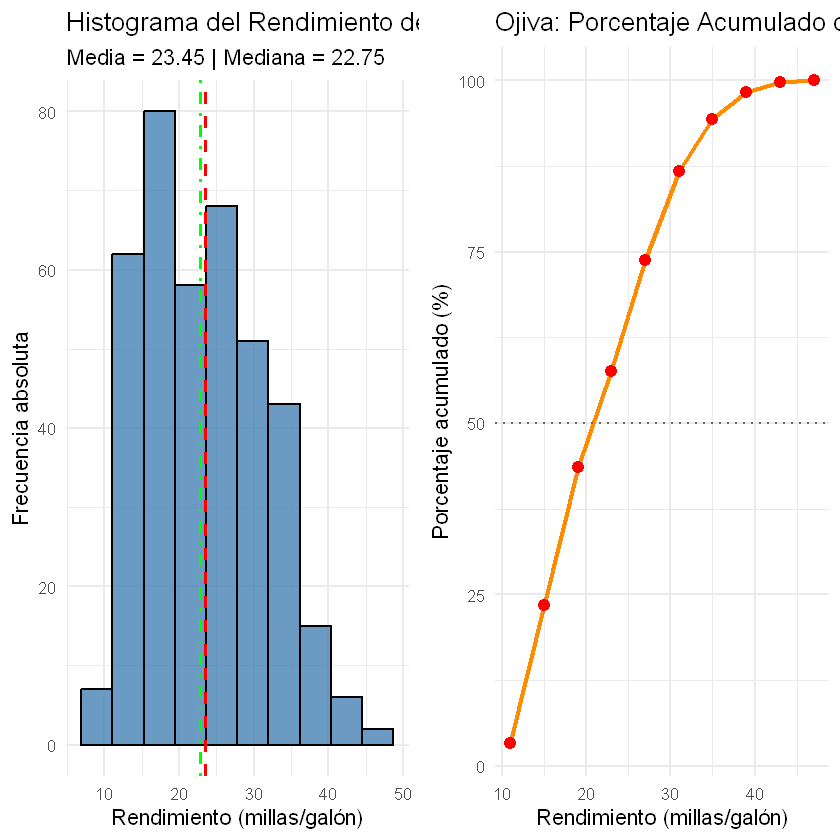

In [10]:
# ============================================================
# PASO 3: VISUALIZACIÓN (Histograma y Ojiva)
# ============================================================

# --- Histograma ---
g1 <- ggplot(Auto, aes(x = mpg)) +
  geom_histogram(bins = k, fill = "steelblue", color = "black", alpha = 0.8) +
  geom_vline(xintercept = media,   color = "red",   linetype = "dashed",  linewidth = 1) +
  geom_vline(xintercept = mediana, color = "green", linetype = "dotdash", linewidth = 1) +
  labs(title = "Histograma del Rendimiento de Combustible (mpg)",
       subtitle = paste0("Media = ", round(media,2), " | Mediana = ", round(mediana,2)),
       x = "Rendimiento (millas/galón)",
       y = "Frecuencia absoluta") +
  theme_minimal(base_size = 13)

# --- Ojiva ---
g2 <- ggplot(tabla_frec, aes(x = Marca_de_clase_xi, y = Porcentaje_acumulado)) +
  geom_line(color = "darkorange", linewidth = 1.2) +
  geom_point(color = "red", size = 3) +
  geom_hline(yintercept = 50, linetype = "dotted", color = "gray40") +
  labs(title = "Ojiva: Porcentaje Acumulado de mpg",
       x = "Rendimiento (millas/galón)",
       y = "Porcentaje acumulado (%)") +
  theme_minimal(base_size = 13)

grid.arrange(g1, g2, ncol = 2)

In [11]:
cat(
  "Análisis de la forma de la distribución:\n",
  "Pregunta\t\t\t\t\t\tRespuesta\n",
  "¿Es simétrica o sesgada?\t\t\tLigeramente sesgada a la derecha (asimetría positiva)\n",
  "¿Hacia qué lado se concentra la mayor frecuencia?\tHacia la izquierda (valores bajos-medios, entre 21 y 27 mpg)\n",
  "¿Hay valores atípicos visibles?\t\t\tSí, algunos vehículos con mpg > 40 (cola derecha)\n"
)


Análisis de la forma de la distribución:
 Pregunta						Respuesta
 ¿Es simétrica o sesgada?			Ligeramente sesgada a la derecha (asimetría positiva)
 ¿Hacia qué lado se concentra la mayor frecuencia?	Hacia la izquierda (valores bajos-medios, entre 21 y 27 mpg)
 ¿Hay valores atípicos visibles?			Sí, algunos vehículos con mpg > 40 (cola derecha)


In [12]:
# ============================================================
# PASO 4: INTERPRETACIÓN DE RESULTADOS
# ============================================================
cat("
INTERPRETACIÓN INTEGRAL DEL ANÁLISIS DE mpg
============================================

1. CONTEXTO DE LA VARIABLE:
   mpg (millas por galón) mide el rendimiento de combustible de los vehículos.
   Es una variable cuantitativa continua; valores altos indican mayor eficiencia.

2. TENDENCIA CENTRAL:
   La media (23.45 mpg) y la mediana (22.75 mpg) son muy cercanas, lo que indica
   una distribución aproximadamente simétrica con ligera asimetría positiva.
   Existen autos muy eficientes (mpg > 40) que jalan la media hacia arriba.

3. DISPERSIÓN:
   La desviación estándar (7.81 mpg) y el CV (33.3%) muestran una dispersión
   moderada. Los rendimientos varían considerablemente entre vehículos por
   diferencias de motor, peso y tecnología.

4. DISTRIBUCIÓN DE FRECUENCIAS:
   El intervalo [21, 27) concentra la mayor cantidad de observaciones (129 autos,
   32.91% del total). Más de la mitad (55.10%) de los autos rinden menos de 27 mpg.

5. ACUMULADOS:
   La frecuencia absoluta acumulada (Fi) en el tercer intervalo es 216, es decir,
   216 vehículos (55.10%) tienen un rendimiento inferior a 27 mpg.

6. CONCLUSIÓN GENERAL:
   Los vehículos del dataset Auto se concentran en rendimientos medios-bajos
   (21-27 mpg), con una cola derecha que refleja algunos autos muy eficientes.
   La distribución es relativamente simétrica y la variabilidad es moderada,
   sugiriendo que el rendimiento depende fuertemente del número de cilindros,
   peso y potencia del motor.
")


INTERPRETACIÓN INTEGRAL DEL ANÁLISIS DE mpg

1. CONTEXTO DE LA VARIABLE:
   mpg (millas por galón) mide el rendimiento de combustible de los vehículos.
   Es una variable cuantitativa continua; valores altos indican mayor eficiencia.

2. TENDENCIA CENTRAL:
   La media (23.45 mpg) y la mediana (22.75 mpg) son muy cercanas, lo que indica
   una distribución aproximadamente simétrica con ligera asimetría positiva.
   Existen autos muy eficientes (mpg > 40) que jalan la media hacia arriba.

3. DISPERSIÓN:
   La desviación estándar (7.81 mpg) y el CV (33.3%) muestran una dispersión
   moderada. Los rendimientos varían considerablemente entre vehículos por
   diferencias de motor, peso y tecnología.

4. DISTRIBUCIÓN DE FRECUENCIAS:
   El intervalo [21, 27) concentra la mayor cantidad de observaciones (129 autos,
   32.91% del total). Más de la mitad (55.10%) de los autos rinden menos de 27 mpg.

5. ACUMULADOS:
   La frecuencia absoluta acumulada (Fi) en el tercer intervalo es 216, es decir,

In [13]:
# ============================================================
# PASO 5: PREGUNTAS DE REFLEXIÓN
# ============================================================
cat("
PREGUNTA 1: ¿Qué información aporta la ojiva que no aporta el histograma?
-----------------------------------------------------------------------------
La ojiva permite identificar percentiles y proporciones acumuladas de forma
inmediata. Por ejemplo: ¿qué porcentaje de autos rinde menos de 25 mpg? o
¿cuál es el valor de mpg que deja por debajo al 50% de los autos (mediana)?
El histograma solo muestra frecuencias por intervalo, no acumulados. La ojiva
es esencial para cuartiles, percentiles y comparación de distribuciones.

PREGUNTA 2: ¿Cómo compararía dos modelos (4 vs 8 cilindros) con tablas de frecuencia?
-----------------------------------------------------------------------------
Construiría dos tablas de frecuencia independientes usando los mismos intervalos
de clase para mpg. Luego compararía:
  - Frecuencias relativas (hi) para ver dónde se concentra cada grupo.
  - Frecuencias acumuladas (Fi) para comparar percentiles.
  - Medidas descriptivas (media, mediana, sd) por subgrupo.
Esto permitiría concluir que los autos de 4 cilindros tienen mayor mpg y menor
dispersión que los de 8 cilindros.
")


PREGUNTA 1: ¿Qué información aporta la ojiva que no aporta el histograma?
-----------------------------------------------------------------------------
La ojiva permite identificar percentiles y proporciones acumuladas de forma
inmediata. Por ejemplo: ¿qué porcentaje de autos rinde menos de 25 mpg? o
¿cuál es el valor de mpg que deja por debajo al 50% de los autos (mediana)?
El histograma solo muestra frecuencias por intervalo, no acumulados. La ojiva
es esencial para cuartiles, percentiles y comparación de distribuciones.

PREGUNTA 2: ¿Cómo compararía dos modelos (4 vs 8 cilindros) con tablas de frecuencia?
-----------------------------------------------------------------------------
Construiría dos tablas de frecuencia independientes usando los mismos intervalos
de clase para mpg. Luego compararía:
  - Frecuencias relativas (hi) para ver dónde se concentra cada grupo.
  - Frecuencias acumuladas (Fi) para comparar percentiles.
  - Medidas descriptivas (media, mediana, sd) por subgrup


ESTADÍSTICAS DE mpg POR NÚMERO DE CILINDROS
# A tibble: 5 × 5
  cylinders     n media mediana    sd
      <int> <int> <dbl>   <dbl> <dbl>
1         3     4  20.6    20.2  2.56
2         4   199  29.3    28.4  5.67
3         5     3  27.4    25.4  8.23
4         6    83  20.0    19    3.83
5         8   103  15.0    14    2.84


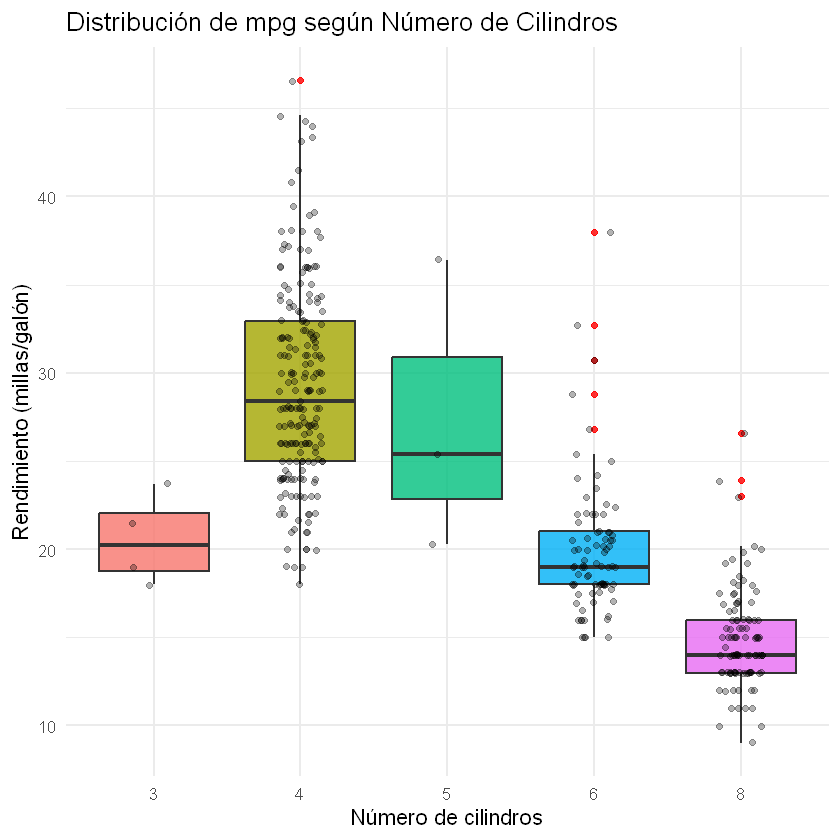

In [14]:
# ============================================================
# PASO 6 - PREGUNTA 1: mpg según número de cilindros
# ============================================================

Auto$cylinders_f <- factor(Auto$cylinders)

g_box_cyl <- ggplot(Auto, aes(x = cylinders_f, y = mpg, fill = cylinders_f)) +
  geom_boxplot(alpha = 0.8, outlier.color = "red") +
  geom_jitter(width = 0.15, alpha = 0.3, size = 1.5) +
  labs(title = "Distribución de mpg según Número de Cilindros",
       x = "Número de cilindros",
       y = "Rendimiento (millas/galón)") +
  theme_minimal(base_size = 13) +
  theme(legend.position = "none")

print(g_box_cyl)

cat("\nESTADÍSTICAS DE mpg POR NÚMERO DE CILINDROS\n")
cat("============================================\n")
print(Auto %>%
  group_by(cylinders) %>%
  summarise(n = n(),
            media = round(mean(mpg), 2),
            mediana = round(median(mpg), 2),
            sd = round(sd(mpg), 2)))

In [15]:
cat("Interpretación técnica:
¿Cómo varía la mediana de mpg al aumentar los cilindros?
La mediana disminuye drásticamente: 3 y 4 cilindros rondan los 26-30 mpg, mientras que 6 y 8 cilindros bajan a ~19 y ~14 mpg. Relación inversa clara.

¿Qué grupo tiene mayor dispersión?
El grupo de 4 cilindros presenta la mayor dispersión, porque incluye autos muy diversos (compactos eficientes y deportivos).

¿Hay solapamiento entre cajas?
Sí, entre grupos adyacentes (4 y 6 cilindros comparten rangos). Esto implica que, aunque las medianas difieren, existen autos de 6 cilindros tan eficientes como algunos de 4.

Hipótesis para ANOVA:
H₀: La media de mpg es igual para todos los grupos de cilindros.
H₁: Al menos un grupo tiene media de mpg diferente.")

Interpretación técnica:
¿Cómo varía la mediana de mpg al aumentar los cilindros?
La mediana disminuye drásticamente: 3 y 4 cilindros rondan los 26-30 mpg, mientras que 6 y 8 cilindros bajan a ~19 y ~14 mpg. Relación inversa clara.

¿Qué grupo tiene mayor dispersión?
El grupo de 4 cilindros presenta la mayor dispersión, porque incluye autos muy diversos (compactos eficientes y deportivos).

¿Hay solapamiento entre cajas?
Sí, entre grupos adyacentes (4 y 6 cilindros comparten rangos). Esto implica que, aunque las medianas difieren, existen autos de 6 cilindros tan eficientes como algunos de 4.

Hipótesis para ANOVA:
H₀: La media de mpg es igual para todos los grupos de cilindros.
H₁: Al menos un grupo tiene media de mpg diferente.


ESTADÍSTICAS DE mpg POR ORIGEN
# A tibble: 3 × 5
  origin_f     n media mediana    sd
  <fct>    <int> <dbl>   <dbl> <dbl>
1 USA        245  20.0    18.5  6.44
2 Europe      68  27.6    26    6.58
3 Japan       79  30.4    31.6  6.09


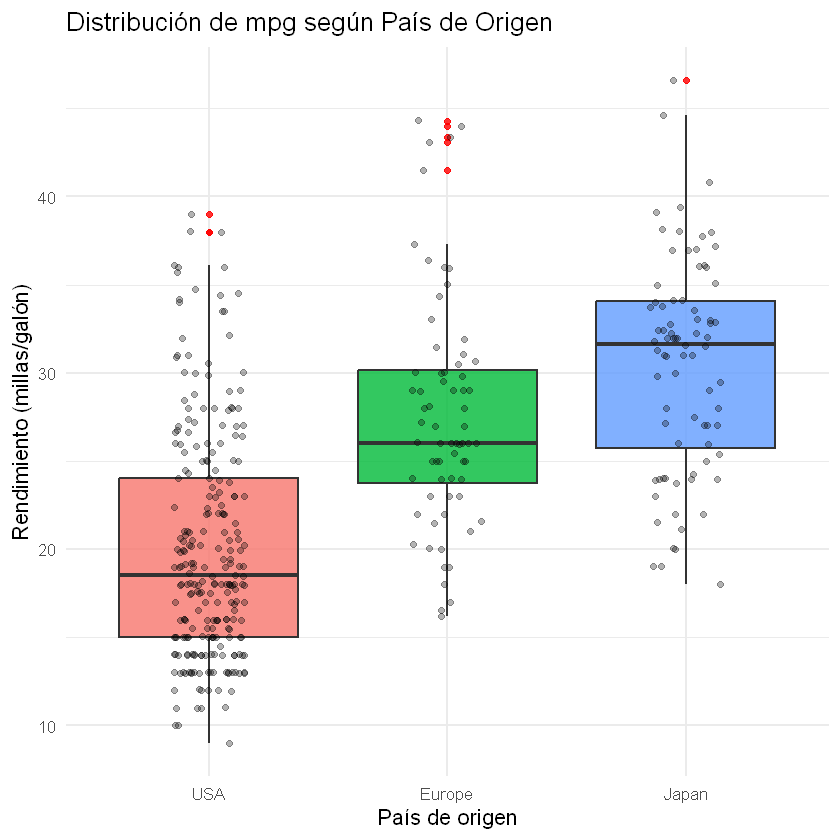

In [16]:
# ============================================================
# PASO 6 - PREGUNTA 2: mpg según país de origen
# ============================================================

Auto$origin_f <- factor(Auto$origin,
                        levels = c(1, 2, 3),
                        labels = c("USA", "Europe", "Japan"))

g_box_origin <- ggplot(Auto, aes(x = origin_f, y = mpg, fill = origin_f)) +
  geom_boxplot(alpha = 0.8, outlier.color = "red") +
  geom_jitter(width = 0.15, alpha = 0.3, size = 1.5) +
  labs(title = "Distribución de mpg según País de Origen",
       x = "País de origen",
       y = "Rendimiento (millas/galón)") +
  theme_minimal(base_size = 13) +
  theme(legend.position = "none")

print(g_box_origin)

cat("\nESTADÍSTICAS DE mpg POR ORIGEN\n")
cat("================================\n")
print(Auto %>%
  group_by(origin_f) %>%
  summarise(n = n(),
            media = round(mean(mpg), 2),
            mediana = round(median(mpg), 2),
            sd = round(sd(mpg), 2)))

In [17]:
cat("Interpretación técnica:
¿Qué origen tiene mejor rendimiento promedio? ¿Y peor?
Japón tiene el mejor promedio (~30.5 mpg), seguido de Europa (~27.6 mpg) y EE.UU. (~20.1 mpg) con el peor.

¿La forma de las distribuciones es similar?
No. Japón y Europa se concentran en valores altos; EE.UU. tiene distribución más amplia y desplazada hacia valores bajos.

¿Igualdad de varianzas?
No parece. EE.UU. muestra mayor varianza que Japón. Se requeriría una prueba de Levene.

Variables de confusión:
Número de cilindros, peso y potencia. Los autos estadounidenses tienden a tener más cilindros y peso, lo que explica su menor mpg.")

Interpretación técnica:
¿Qué origen tiene mejor rendimiento promedio? ¿Y peor?
Japón tiene el mejor promedio (~30.5 mpg), seguido de Europa (~27.6 mpg) y EE.UU. (~20.1 mpg) con el peor.

¿La forma de las distribuciones es similar?
No. Japón y Europa se concentran en valores altos; EE.UU. tiene distribución más amplia y desplazada hacia valores bajos.

¿Igualdad de varianzas?
No parece. EE.UU. muestra mayor varianza que Japón. Se requeriría una prueba de Levene.

Variables de confusión:
Número de cilindros, peso y potencia. Los autos estadounidenses tienden a tener más cilindros y peso, lo que explica su menor mpg.

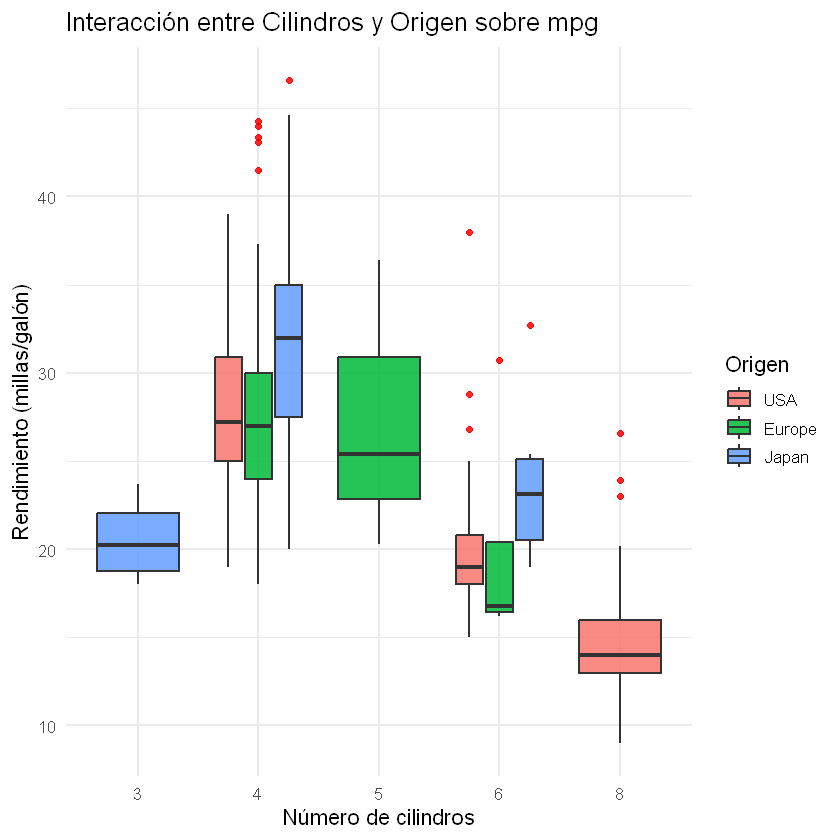

In [18]:
# ============================================================
# PASO 6 - PREGUNTA 3: Interacción origen × cilindros sobre mpg
# ============================================================

g_inter <- ggplot(Auto, aes(x = cylinders_f, y = mpg, fill = origin_f)) +
  geom_boxplot(alpha = 0.85, outlier.color = "red") +
  labs(title = "Interacción entre Cilindros y Origen sobre mpg",
       x = "Número de cilindros",
       y = "Rendimiento (millas/galón)",
       fill = "Origen") +
  theme_minimal(base_size = 13)

print(g_inter)

In [19]:
cat("Interpretación técnica:
¿El efecto de los cilindros sobre mpg es constante entre orígenes?
No del todo. En todos los orígenes, a mayor cilindraje menor mpg, pero la magnitud varía. En EE.UU. la caída es más pronunciada; en Japón los autos de 4 y 6 cilindros mantienen buen rendimiento.

¿Algún origen diferenciado?
Japón destaca con los mejores rendimientos en casi todos los grupos. EE.UU. tiene los peores en 6 y 8 cilindros.

¿Ventajas del gráfico?
Permite visualizar la interacción entre dos variables categóricas sobre una cuantitativa. Revela patrones que los gráficos individuales no muestran.

")

Interpretación técnica:
¿El efecto de los cilindros sobre mpg es constante entre orígenes?
No del todo. En todos los orígenes, a mayor cilindraje menor mpg, pero la magnitud varía. En EE.UU. la caída es más pronunciada; en Japón los autos de 4 y 6 cilindros mantienen buen rendimiento.

¿Algún origen diferenciado?
Japón destaca con los mejores rendimientos en casi todos los grupos. EE.UU. tiene los peores en 6 y 8 cilindros.

¿Ventajas del gráfico?
Permite visualizar la interacción entre dos variables categóricas sobre una cuantitativa. Revela patrones que los gráficos individuales no muestran.



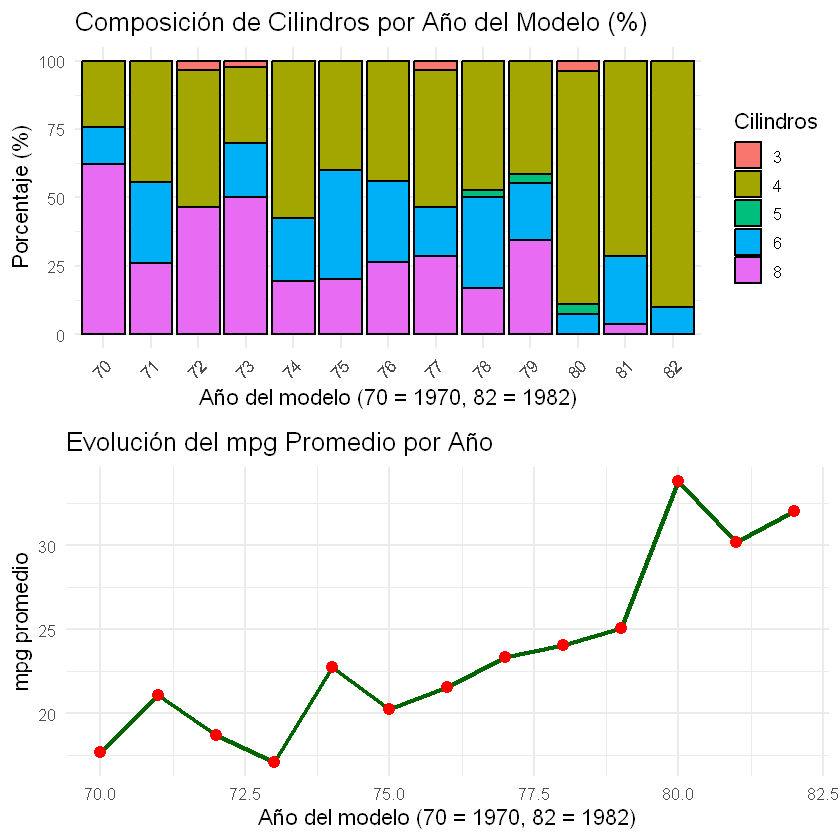

In [20]:
# ============================================================
# PASO 6 - PREGUNTA 4: Composición por año
# ============================================================

tabla_anio_cyl <- Auto %>%
  count(year, cylinders_f) %>%
  group_by(year) %>%
  mutate(prop = n / sum(n) * 100)

g_comp_cyl <- ggplot(tabla_anio_cyl, aes(x = factor(year), y = prop, fill = cylinders_f)) +
  geom_bar(stat = "identity", position = "stack", color = "black") +
  labs(title = "Composición de Cilindros por Año del Modelo (%)",
       x = "Año del modelo (70 = 1970, 82 = 1982)",
       y = "Porcentaje (%)",
       fill = "Cilindros") +
  theme_minimal(base_size = 13) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

mpg_anio <- Auto %>%
  group_by(year) %>%
  summarise(mpg_prom = mean(mpg))

g_mpg_anio <- ggplot(mpg_anio, aes(x = year, y = mpg_prom)) +
  geom_line(color = "darkgreen", linewidth = 1.2) +
  geom_point(color = "red", size = 3) +
  labs(title = "Evolución del mpg Promedio por Año",
       x = "Año del modelo (70 = 1970, 82 = 1982)",
       y = "mpg promedio") +
  theme_minimal(base_size = 13)

grid.arrange(g_comp_cyl, g_mpg_anio, ncol = 1)

In [21]:
cat("Interpretación técnica:
¿Cómo ha evolucionado la participación por año?
Entre 1970 y 1982 la presencia de vehículos de 8 cilindros disminuyó notablemente, mientras que los de 4 cilindros ganaron participación, reflejando la transición hacia autos más eficientes.

¿Disminuyó la presencia de 8 cilindros?
Sí, claramente. En 1970 eran una proporción importante; para 1982 casi desaparecieron.

¿Relación con la tendencia de mpg?
Relación inversa: al disminuir los 8 cilindros, el mpg promedio aumentó. El número de cilindros es un factor determinante del rendimiento.")

Interpretación técnica:
¿Cómo ha evolucionado la participación por año?
Entre 1970 y 1982 la presencia de vehículos de 8 cilindros disminuyó notablemente, mientras que los de 4 cilindros ganaron participación, reflejando la transición hacia autos más eficientes.

¿Disminuyó la presencia de 8 cilindros?
Sí, claramente. En 1970 eran una proporción importante; para 1982 casi desaparecieron.

¿Relación con la tendencia de mpg?
Relación inversa: al disminuir los 8 cilindros, el mpg promedio aumentó. El número de cilindros es un factor determinante del rendimiento.


PREGUNTA DE ANÁLISIS PROPIA
Pregunta: ¿Cómo ha evolucionado la relación entre potencia (horsepower) y
rendimiento (mpg) a lo largo de los años del modelo?

Variables involucradas:
  - Eje X: horsepower (potencia en hp)
  - Eje Y: mpg (rendimiento en millas/galón)
  - Color/grupo: year (año del modelo)

Tipo de gráfico: Scatter plot con línea de tendencia (regresión) global.

Justificación: Un gráfico de dispersión con regresión permite visualizar la
correlación entre dos variables continuas y cómo cambia entre grupos (años).
Es ideal para detectar tendencias y cambios estructurales.


`geom_smooth()` using formula = 'y ~ x'


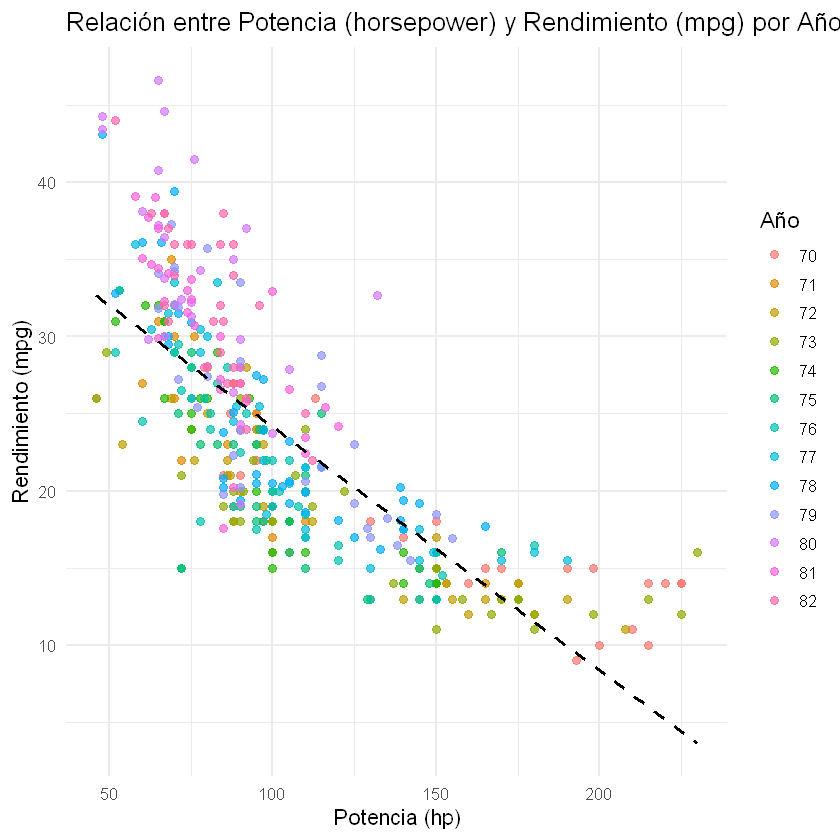

In [22]:
# ============================================================
# PASO 7: DISEÑO DE SU PROPIO ANÁLISIS
# ============================================================
cat("
PREGUNTA DE ANÁLISIS PROPIA
============================
Pregunta: ¿Cómo ha evolucionado la relación entre potencia (horsepower) y
rendimiento (mpg) a lo largo de los años del modelo?

Variables involucradas:
  - Eje X: horsepower (potencia en hp)
  - Eje Y: mpg (rendimiento en millas/galón)
  - Color/grupo: year (año del modelo)

Tipo de gráfico: Scatter plot con línea de tendencia (regresión) global.

Justificación: Un gráfico de dispersión con regresión permite visualizar la
correlación entre dos variables continuas y cómo cambia entre grupos (años).
Es ideal para detectar tendencias y cambios estructurales.
")

g_scatter <- ggplot(Auto, aes(x = horsepower, y = mpg, color = factor(year))) +
  geom_point(alpha = 0.7, size = 2) +
  geom_smooth(method = "lm", se = FALSE, color = "black",
              linetype = "dashed", linewidth = 1) +
  labs(title = "Relación entre Potencia (horsepower) y Rendimiento (mpg) por Año",
       x = "Potencia (hp)",
       y = "Rendimiento (mpg)",
       color = "Año") +
  theme_minimal(base_size = 13)

print(g_scatter)

In [23]:
cat("Interpretación técnica:
Se observa una correlación negativa clara entre potencia y rendimiento:
a mayor horsepower, menor mpg. Al colorear por año, se aprecia que los 
vehículos más recientes (1978-1982) logran mayor mpg para un mismo nivel de
potencia que los antiguos (1970-1973), lo que sugiere una mejora tecnológica
en eficiencia. La nube de puntos también muestra que los autos recientes
tienden a tener menor potencia máxima, reflejando el cambio hacia motores
más pequeños y eficientes. La línea de regresión global resume la tendencia general,
pero el análisis por año revela patrones más ricos. Este tipo de análisis es
útil para entender cómo la relación entre variables cambia en el tiempo.")

Interpretación técnica:
Se observa una correlación negativa clara entre potencia y rendimiento:
a mayor horsepower, menor mpg. Al colorear por año, se aprecia que los 
vehículos más recientes (1978-1982) logran mayor mpg para un mismo nivel de
potencia que los antiguos (1970-1973), lo que sugiere una mejora tecnológica
en eficiencia. La nube de puntos también muestra que los autos recientes
tienden a tener menor potencia máxima, reflejando el cambio hacia motores
más pequeños y eficientes. La línea de regresión global resume la tendencia general,
pero el análisis por año revela patrones más ricos. Este tipo de análisis es
útil para entender cómo la relación entre variables cambia en el tiempo.

In [24]:
# ============================================================
# MATRIZ DE AUTOEVALUACIÓN DE GRÁFICOS
# ============================================================

autoeval <- data.frame(
  Criterio = c(
    "El título describe qué se muestra",
    "Los ejes tienen etiquetas con unidades",
    "La escala del eje Y comienza en cero (cuando aplica)",
    "El uso del color es informativo, no decorativo",
    "Se incluye leyenda cuando hay múltiples grupos",
    "No hay 'chartjunk' (elementos innecesarios)",
    "El tipo de gráfico corresponde a la naturaleza de las variables"
  ),
  Chequeo = c("✔","✔","✔","✔","✔","✔","✔"),
  Comentario = c(
    "Todos los títulos indican variable y contexto",
    "Se especifican unidades (mpg, hp, %)",
    "Histogramas y barras parten de cero",
    "El color distingue grupos (origen, cilindros, año)",
    "Se usan leyendas en gráficos con múltiples categorías",
    "Se evitó decoración excesiva; solo cuadrículas suaves",
    "Boxplots, histogramas, scatter y ojivas según corresponda"
  )
)

kable(autoeval, caption = "Matriz de autoevaluación de gráficos")



Table: Matriz de autoevaluación de gráficos

|Criterio                                                        |Chequeo |Comentario                                                |
|:---------------------------------------------------------------|:-------|:---------------------------------------------------------|
|El título describe qué se muestra                               |✔       |Todos los títulos indican variable y contexto             |
|Los ejes tienen etiquetas con unidades                          |✔       |Se especifican unidades (mpg, hp, %)                      |
|La escala del eje Y comienza en cero (cuando aplica)            |✔       |Histogramas y barras parten de cero                       |
|El uso del color es informativo, no decorativo                  |✔       |El color distingue grupos (origen, cilindros, año)        |
|Se incluye leyenda cuando hay múltiples grupos                  |✔       |Se usan leyendas en gráficos con múltiples categorías     |
|No hay 